# Course 2 · Week 3 — Solution: Bias, Variance, and Learning Curves


## Setup — noisy samples from a curve

Underlying truth: `y = sin(1.5x)` plus Gaussian noise. We sample 90 points and split them 60/20/20 into train / cv / test. The model only sees train; we evaluate on cv to pick hyperparameters; we touch test exactly once at the end for an honest report.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def true_fn(x):
    return np.sin(1.5 * x)

# Generate noisy samples from a curvy function
n_total = 90
X_all = np.random.uniform(-3, 3, n_total)
y_all = true_fn(X_all) + np.random.normal(0, 0.25, n_total)

# 60/20/20 train/cv/test split
idx = np.random.permutation(n_total)
n_train = int(n_total * 0.6); n_cv = int(n_total * 0.2)
i_train, i_cv, i_test = idx[:n_train], idx[n_train:n_train+n_cv], idx[n_train+n_cv:]
X_train, y_train = X_all[i_train], y_all[i_train]
X_cv,    y_cv    = X_all[i_cv],    y_all[i_cv]
X_test,  y_test  = X_all[i_test],  y_all[i_test]

print(f"train: {len(X_train)}, cv: {len(X_cv)}, test: {len(X_test)}")


train: 54, cv: 18, test: 18


Three colors of dots. The dashed line is the true function — but in real life you never see it. You only see the dots and have to figure out the rest.


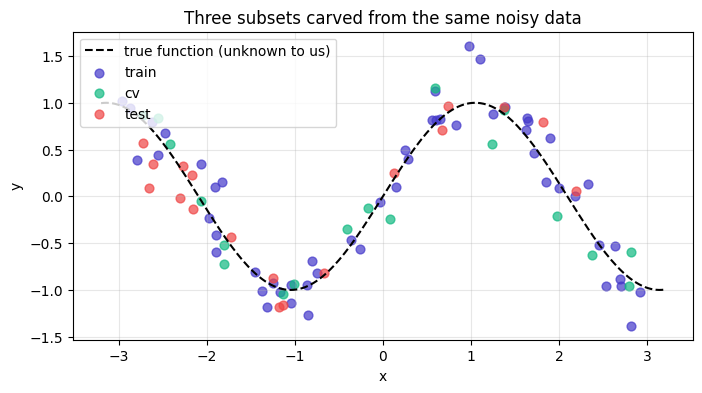

In [2]:
xs = np.linspace(-3.2, 3.2, 200)
plt.figure(figsize=(8, 4))
plt.plot(xs, true_fn(xs), color="black", lw=1.5, ls="--", label="true function (unknown to us)")
plt.scatter(X_train, y_train, color="#4338ca", s=40, alpha=0.7, label="train")
plt.scatter(X_cv,    y_cv,    color="#10b981", s=40, alpha=0.7, label="cv")
plt.scatter(X_test,  y_test,  color="#ef4444", s=40, alpha=0.7, label="test")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.grid(alpha=0.3)
plt.title("Three subsets carved from the same noisy data")
plt.show()


## Quick recap (with depth)

### Why three sets?

If you tune your model using only train+test, then your test error is biased — you've effectively peeked. The CV set lets you tune (try many models, pick by cv error) without contaminating the test set. The test set is your "exam day" — touched exactly once at the end.

### Bias vs variance — symptom map

| | J_train | J_cv | Diagnosis |
|---|---|---|---|
| both high, similar | high | high | **High bias** — model can't represent the function. Try bigger / more features / less regularization. |
| big gap | low | high | **High variance** — model memorized noise. Try more data / simpler model / more regularization. |
| both low | low | low | Sweet spot. Ship it. |

### The bias-variance plot

As model complexity grows from "too simple" to "too complex":
- J_train monotonically decreases (bigger models can always fit better)
- J_cv decreases, then *increases* (the U-shape that gives the optimal complexity)

The minimum of J_cv is the sweet spot. That's the whole game.


## Exercise 1 — MSE

```python
def mse(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2))
```


In [3]:
def poly_features(x, degree):
    return np.column_stack([x**(d+1) for d in range(degree)])

def fit(X, y, lam=0.0):
    X_aug = np.column_stack([np.ones(len(X)), X])
    n = X_aug.shape[1]
    A = X_aug.T @ X_aug + lam * np.eye(n)
    A[0, 0] -= lam
    return np.linalg.solve(A, X_aug.T @ y)

def predict(X, theta):
    return np.column_stack([np.ones(len(X)), X]) @ theta

def mse(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2))

assert mse(np.array([1,2,3]), np.array([1,2,3])) == 0
assert abs(mse(np.array([1.,2.]), np.array([3.,4.])) - 4.0) < 1e-9
print("✓ mse() works")


✓ mse() works


## Exercise 2 — degree sweep

The classic bias-variance picture. Expected:

| degree | J_train | J_cv | what's happening |
|---|---|---|---|
| 1 | 0.64 | 0.50 | high bias — straight line can't fit a sine curve |
| 2 | 0.64 | 0.50 | still bias |
| 4 | 0.13 | 0.16 | sweet spot — flexible enough, not too flexible |
| 8 | 0.05 | 0.09 | borderline; J_cv slightly worse |
| 12 | 0.04 | 0.10 | variance creeping in — gap widening |

The cv-minimum sits around degree 4–8. Beyond that you're chasing noise.


degree     J_train        J_cv
     1      0.6446      0.4953
     2      0.6415      0.4988
     4      0.1276      0.1606
     8      0.0458      0.0851
    12      0.0402      0.0987


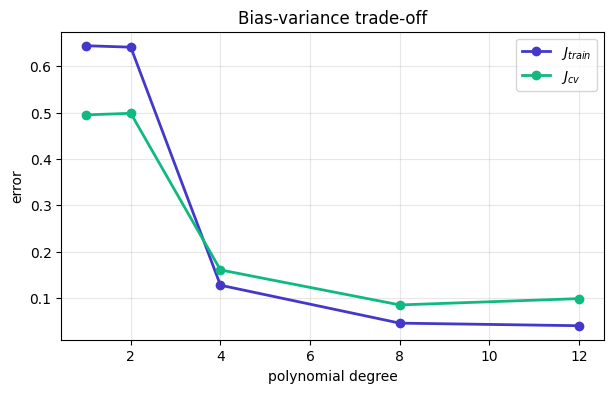

In [4]:
degrees = [1, 2, 4, 8, 12]
results = []
for d in degrees:
    Xtr = poly_features(X_train, d)
    Xcv = poly_features(X_cv, d)
    theta = fit(Xtr, y_train)
    Jtr = mse(y_train, predict(Xtr, theta))
    Jcv = mse(y_cv, predict(Xcv, theta))
    results.append((d, Jtr, Jcv))

print(f"{'degree':>6}  {'J_train':>10}  {'J_cv':>10}")
for d, jtr, jcv in results:
    print(f"{d:>6}  {jtr:>10.4f}  {jcv:>10.4f}")

ds = [r[0] for r in results]
plt.figure(figsize=(7, 4))
plt.plot(ds, [r[1] for r in results], "o-", color="#4338ca", lw=2, label="$J_{train}$")
plt.plot(ds, [r[2] for r in results], "o-", color="#10b981", lw=2, label="$J_{cv}$")
plt.xlabel("polynomial degree"); plt.ylabel("error")
plt.legend(); plt.grid(alpha=0.3); plt.title("Bias-variance trade-off")
plt.show()


## Visual: under-, just-right, and overfit

Three plots side by side. Watch how the red curve hugs the data:

- **Degree 1:** straight line through curvy data — terrible fit (high bias).
- **Degree 4:** smooth curve following the underlying sine pattern (just right).
- **Degree 12:** wiggly curve tortured to pass through specific noisy points (overfit / high variance).


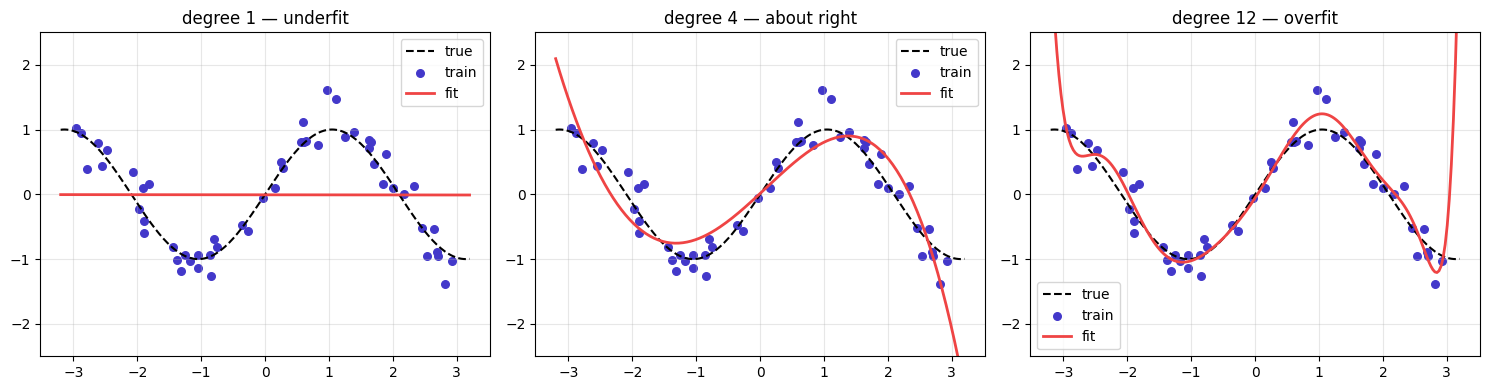

In [5]:
# Show three fits visually: degree 1 (underfit), degree 4 (good), degree 12 (overfit).
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
xs_plot = np.linspace(-3.2, 3.2, 200)
for ax, d, label in zip(axes, [1, 4, 12], ["degree 1 — underfit", "degree 4 — about right", "degree 12 — overfit"]):
    Xtr = poly_features(X_train, d)
    theta = fit(Xtr, y_train)
    y_plot = predict(poly_features(xs_plot, d), theta)
    ax.plot(xs_plot, true_fn(xs_plot), color="black", ls="--", label="true")
    ax.scatter(X_train, y_train, color="#4338ca", s=30, label="train")
    ax.plot(xs_plot, y_plot, color="#ef4444", lw=2, label=f"fit")
    ax.set_title(label); ax.legend(); ax.grid(alpha=0.3)
    ax.set_ylim(-2.5, 2.5)
plt.tight_layout(); plt.show()


## Exercise 3 — learning curves

Expected pattern at degree=8:

| m | J_train | J_cv |
|---|---|---|
| 3 | 0.0000 | 3.91 |
| 6 | 0.0000 | 130,000,000 (!) |
| 10 | 0.0152 | 263.67 |
| 20 | 0.039 | 0.072 |
| 54 | 0.046 | 0.085 |

The astronomical J_cv at m=6 is real — with only 6 data points and a degree-8 polynomial, the model has 9 parameters fit to 6 points. The system is underdetermined and the fitted polynomial wiggles violently between training points. Adding more data tames it.

This is the visceral demonstration of why "more data" is often the answer.


   m     J_train        J_cv
   3      0.0000      3.9108
   6      0.0000  133627063.8733
  10      0.0152    263.6745
  20      0.0387      0.0719
  30      0.0416      0.0774
  54      0.0458      0.0851


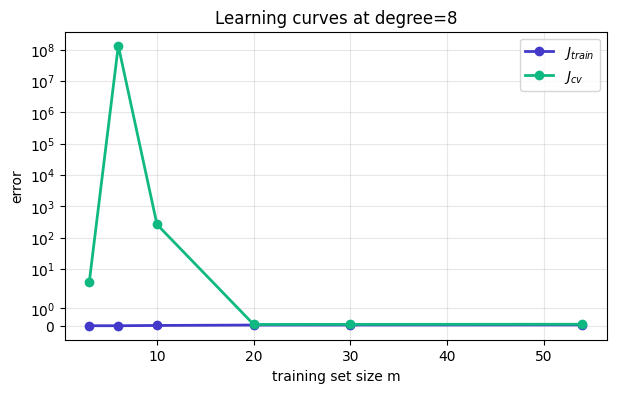

In [6]:
degree = 8
sizes = [3, 6, 10, 20, 30, len(X_train)]
results_lc = []
for size in sizes:
    Xtr = poly_features(X_train[:size], degree)
    Xcv = poly_features(X_cv, degree)
    theta = fit(Xtr, y_train[:size])
    Jtr = mse(y_train[:size], predict(Xtr, theta))
    Jcv = mse(y_cv, predict(Xcv, theta))
    results_lc.append((size, Jtr, Jcv))

print(f"{'m':>4}  {'J_train':>10}  {'J_cv':>10}")
for s, jtr, jcv in results_lc:
    print(f"{s:>4}  {jtr:>10.4f}  {jcv:>10.4f}")

ms = [r[0] for r in results_lc]
plt.figure(figsize=(7, 4))
plt.plot(ms, [r[1] for r in results_lc], "o-", color="#4338ca", lw=2, label="$J_{train}$")
plt.plot(ms, [r[2] for r in results_lc], "o-", color="#10b981", lw=2, label="$J_{cv}$")
plt.xlabel("training set size m"); plt.ylabel("error")
plt.yscale("symlog")
plt.legend(); plt.grid(alpha=0.3); plt.title(f"Learning curves at degree={degree}")
plt.show()


## Exercise 4 — regularization sweep

Expected:

| lambda | J_train | J_cv | ‖theta‖ |
|---|---|---|---|
| 0 | 0.040 | 0.099 | 1.67 |
| 0.001 | 0.040 | 0.099 | 1.67 |
| 0.01 | 0.040 | 0.099 | 1.63 |
| 0.1 | 0.041 | 0.102 | 1.45 |
| 1.0 | 0.046 | 0.096 | 1.17 |
| 10.0 | 0.116 | 0.104 | 0.57 |

Best J_cv is at lambda=1. ‖theta‖ shrinks monotonically — that's regularization at work, pulling weights toward zero.

Notice the pattern: J_train monotonically increases with lambda (we're constraining the fit). J_cv is U-shaped: too little regularization → overfit; too much → underfit. Standard pattern.


In [7]:
degree = 12
lams = [0, 0.001, 0.01, 0.1, 1.0, 10.0]
results_reg = []
for lam in lams:
    Xtr = poly_features(X_train, degree)
    Xcv = poly_features(X_cv, degree)
    theta = fit(Xtr, y_train, lam=lam)
    Jtr = mse(y_train, predict(Xtr, theta))
    Jcv = mse(y_cv, predict(Xcv, theta))
    results_reg.append((lam, Jtr, Jcv, float(np.linalg.norm(theta[1:]))))

print(f"{'lambda':>8}  {'J_train':>10}  {'J_cv':>10}  {'||theta||':>10}")
for lam, jtr, jcv, n in results_reg:
    print(f"{lam:>8}  {jtr:>10.4f}  {jcv:>10.4f}  {n:>10.3f}")

best = min(results_reg, key=lambda r: r[2])
print(f"\nBest lambda by J_cv: {best[0]} (J_cv = {best[2]:.4f})")


  lambda     J_train        J_cv   ||theta||
       0      0.0402      0.0987       1.673
   0.001      0.0402      0.0988       1.669
    0.01      0.0402      0.0993       1.630
     0.1      0.0407      0.1022       1.447
     1.0      0.0463      0.0961       1.166
    10.0      0.1161      0.1040       0.573

Best lambda by J_cv: 1.0 (J_cv = 0.0961)


## ⭐ Stretch — test set evaluation

```python
theta = fit(poly_features(X_train, 12), y_train, lam=1.0)
J_test = mse(y_test, predict(poly_features(X_test, 12), theta))
```

Expected: J_test in the same neighborhood as J_cv (~0.07–0.10). The cv set worked as a valid proxy for the test set.

Important rule: once you peek at test, you can't go back and re-tune. If you do, your "test" set has effectively become a second cv set, and the next number you call "test" isn't honest anymore. People break this rule constantly. Don't.


In [8]:
# Pick best lambda from cv sweep
best_lam = best[0]
degree = 12

Xtr = poly_features(X_train, degree)
Xtest = poly_features(X_test, degree)
theta = fit(Xtr, y_train, lam=best_lam)
J_test = mse(y_test, predict(Xtest, theta))
print(f"With degree=12, lambda={best_lam}:")
print(f"  J_test = {J_test:.4f}")
print(f"\nThis is the FIRST and ONLY time we touched the test set.")
print(f"It's our honest estimate of how the model performs on truly new data.")


With degree=12, lambda=1.0:
  J_test = 0.0641

This is the FIRST and ONLY time we touched the test set.
It's our honest estimate of how the model performs on truly new data.


## Wrap-up

The bias-variance lens is the most useful diagnostic in ML. When your model isn't working, ask:
1. Is J_train high? → high bias → bigger model
2. Is the train/cv gap big? → high variance → more data or regularization
3. Is J_train low and gap small? → great, ship it

Three-tier split (train/cv/test) is the discipline that makes results trustworthy. Tune on cv; report on test; never confuse them.
